<h1>Image Classification using Logistic Regression</h1>

<h2>Installations</h2>

In [3]:
%pip install torch torchvision numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [69]:
import torch 
import torchvision
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transform
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

<h2>Importing Data</h2>

In [6]:
dataset = MNIST(root="data/", download=True)

In [7]:
len(dataset)

60000

In [8]:
test_dataset = MNIST(root="data/", train=False)
len(test_dataset)

10000

In [9]:
dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

Label 5


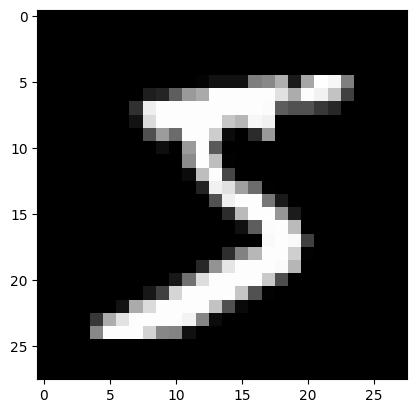

In [21]:
image, label = dataset[0]
plt.imshow(image, cmap="gray")
print("Label", label)

Label 3


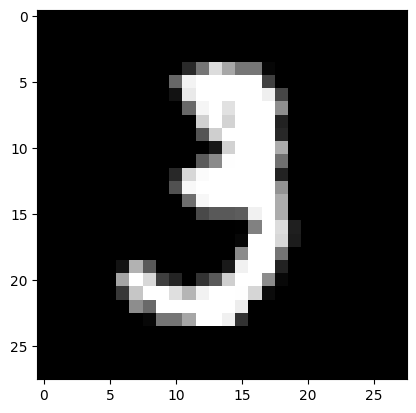

In [23]:
image, label = dataset[10]
plt.imshow(image, cmap="gray")
print("Label", label)

In [29]:
dataset = MNIST(root="data/", train=True, transform=transform.ToTensor())

In [35]:
img_tensor, label = dataset[0]
print(img_tensor.shape, label)

torch.Size([1, 28, 28]) 5


In [39]:
print(img_tensor[:,10:15,10:15])
print(torch.max(img_tensor), torch.min(img_tensor))

tensor([[[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
         [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
         [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
         [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
         [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]]])
tensor(1.) tensor(0.)


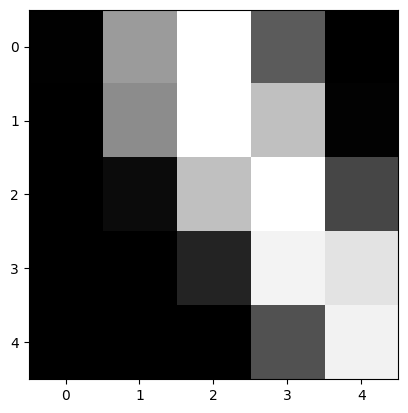

In [49]:
plt.imshow(img_tensor[0,10:15, 10:15], cmap="gray")

<h2>Training and Validation</h2>

In [56]:
def split_indices(n, val_pct):
    #Determine size of validation set
    n_val = int(val_pct*n)
    #Create random permutautions of 0 to n-1
    idxs = np.random.permutation(n)
    #Pick first n_val indices from validation set
    return idxs[n_val:], idxs[:n_val]

In [60]:
train_indices, val_indices = split_indices(n=len(dataset), val_pct=0.2)

In [62]:
print(len(train_indices), len(val_indices))
print("Sample val indices:", val_indices[:20])

48000 12000
Sample val indices: [14186 38272 52120 46606 28089 36182 22967 36138 32404 52644  5182 27620
 30096 54148 52575  3272 44605 43296  4216 21278]


In [71]:
batch_size=100

train_sampler = SubsetRandomSampler(train_indices)
train_loader = DataLoader(dataset,
                          batch_size,
                          sampler=train_sampler)

val_sampler = SubsetRandomSampler(val_indices)
val_loader = DataLoader(dataset,
                          batch_size,
                          sampler=val_sampler)